### Feature Scaling ###
A technique is used to standardize / normalize the independent features present in the data, preventing ones whose values are innumerably larger than others by fitting into a scale or ratio (0 → 1). If this happens, Machine Learning algorithms may misinterpret / neglect other subtle features even if they are crucial for learning accuracy.

There are some ways to perform feature scaling: Standardization, Normalization, Absolute Maximum Scaling, Min-Max Scaling, Robust Scaling.

### Loading Dataset & Customary Practices ###

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [29]:
df = pd.read_csv("loan_data_set.csv")
df.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [10]:
#Check for NaN - Missing values
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [12]:
#df["LoanAmount"].fillna(df["LoanAmount"].mean(), inplace = True)

#Using sci-kit learn to fill in NaN values with mean ones (Here LoanAmount column contains many NaN values, thus we need to perform handling missing values)

si = SimpleImputer(strategy = "mean")
df["LoanAmount"] = si.fit_transform(df[["LoanAmount"]])

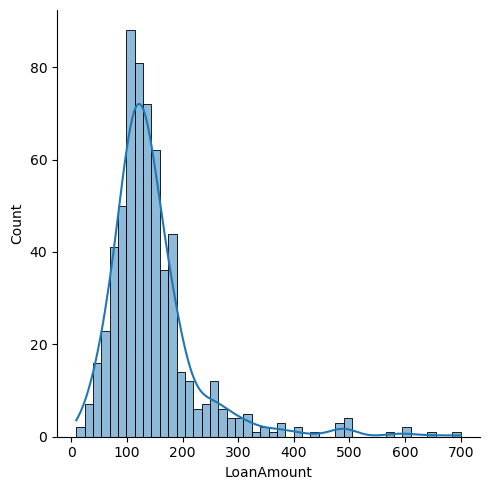

In [27]:
#Visualisation on LoanAmount feature
sns.displot(x = df["LoanAmount"], kde = True)

In [16]:
#Displaying statistical values
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,84.037468,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.250000,360.00000,1.000000
50%,3812.500000,1188.500000,129.000000,360.00000,1.000000
75%,5795.000000,2297.250000,164.750000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


### Standardization Method (Sci-kit Learn) ###

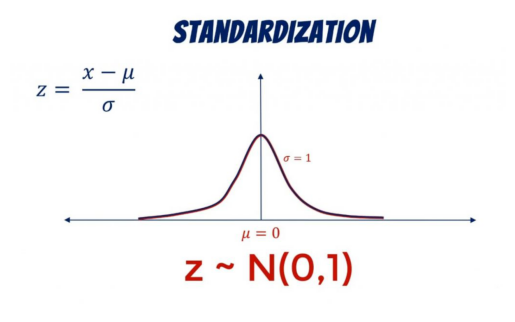

In [19]:
img = mpimg.imread("standardization.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()

In [21]:
ss = StandardScaler() #The dataframe must be in 2D
ss.fit(df[["CoapplicantIncome"]])

StandardScaler()

In [23]:
df["CoapplicantIncome_ss"] = pd.DataFrame(ss.transform(df[["CoapplicantIncome"]]), columns = ["x"])
df.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,CoapplicantIncome_ss
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y,-0.554487
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N,-0.038732
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y,-0.554487
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y,0.251980
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y,-0.554487


C:\Users\Cresht\AppData\Local\Temp\ipykernel_8880\1646123326.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x = df["CoapplicantIncome"], kde = True)
C:\Users\Cresht\AppData\Local\Temp\ipykernel_8880\1646123326.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x = df["CoapplicantIncome_ss"

<Axes: title={'center': 'After'}, ylabel='Density'>

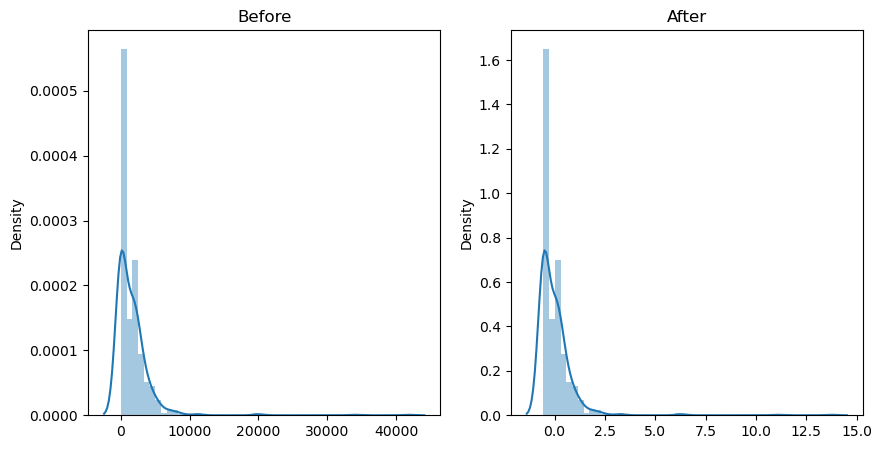

In [25]:
plt.figure(figsize = (10, 5))
plt.subplot(1, 2, 1)
plt.title("Before")
sns.distplot(x = df["CoapplicantIncome"], kde = True)

plt.subplot(1, 2, 2)
plt.title("After")
sns.distplot(x = df["CoapplicantIncome_ss"], kde = True)